In [65]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append('../')
from esn import ESN, ESNConfig

In [175]:
import h5py

with h5py.File('/Users/iliasoroka/RC/data_eigenworm/crawl.mat', 'r') as f:
    tr_refs = f['tr'][11]
    print(f"tr shape: {tr_refs.shape}")
    
    tr_data = []
    for ref in tr_refs.flatten():
        data = f[ref][:]
        tr_data.append(data)
        print(f"Data shape: {data.shape}")


tr shape: (1,)
Data shape: (5, 33600)


In [176]:
def filter_nans(pcs):
    nan_mask = np.isnan(pcs).any(axis=0)
    
    valid_indices = np.where(~nan_mask)[0]
    
    indexes_to_skip = []
    for i in range(1, len(valid_indices)):
        if valid_indices[i] - valid_indices[i-1] > 1:
            indexes_to_skip.append(i)
    
    filtered_pcs = pcs[:, ~nan_mask]
    
    return filtered_pcs, indexes_to_skip
all_pcs = []
all_skip_indices = [] 
current_index = 0

for i in range(len(tr_data)):  
    filtered_pcs, gap_indices = filter_nans(tr_data[i][:5, :])
    
    for idx in gap_indices:
        all_skip_indices.append(idx + current_index)
    
    all_pcs.append(filtered_pcs)
    current_index += filtered_pcs.shape[1]
    
    if i < len(tr_data) - 1:
        all_skip_indices.append(current_index)

all_pcs = np.hstack(all_pcs)

In [177]:
from sklearn.preprocessing import StandardScaler
worm_N2_scaled = StandardScaler().fit_transform(all_pcs.T).T

In [165]:
dt = 1/16

In [1]:
import pickle

with open("/Users/iliasoroka/RC/final_config_251229 (2).pkl", "rb") as f:
    config = pickle.load(f)


KeyboardInterrupt: 

In [79]:
config

ESNConfig(N=10000, input_dim=5, spectral_radius=0.1809616855907689, alpha=1.5, sparsity=0.99, input_scaling=1.2665236214415563, bias_scaling=0.01, seed=None, weights_generation_strategy='Gaussian', bias_generation_strategy='Uniform', input_generation_strategy='Uniform', self_connections=False, dtype=dtype('float64'), mode='leaky', leaky_rate=0.7057809844406092, beta=0.5, scale=0.1)

In [14]:
worm_N2_scaled_resampled = worm_N2_scaled[:, ::2]

In [189]:
inputdim = 5
esn = ESN(config)
esn.train(worm_N2_scaled[:inputdim, :], washout=2000)


In [167]:
esn_resampled = ESN(config)
esn_resampled.train(worm_N2_scaled_resampled[:inputdim, :], washout=2000)


In [53]:
esn_resampled.load("/Users/iliasoroka/RC/esn_resampled.pkl.npz")

In [81]:
warmup_data_resampled = worm_N2_scaled_resampled[:inputdim, :2000]
predictions, states = esn_resampled.predict(warmup_data_resampled, steps=5000)

NameError: name 'esn_resampled' is not defined

In [190]:
warmup_data = worm_N2_scaled[:inputdim, 2000:4000]
predictions, states = esn.predict(warmup_data, steps=10000)

In [191]:
read_data_slice = worm_N2_scaled[:inputdim, 4000:14000]

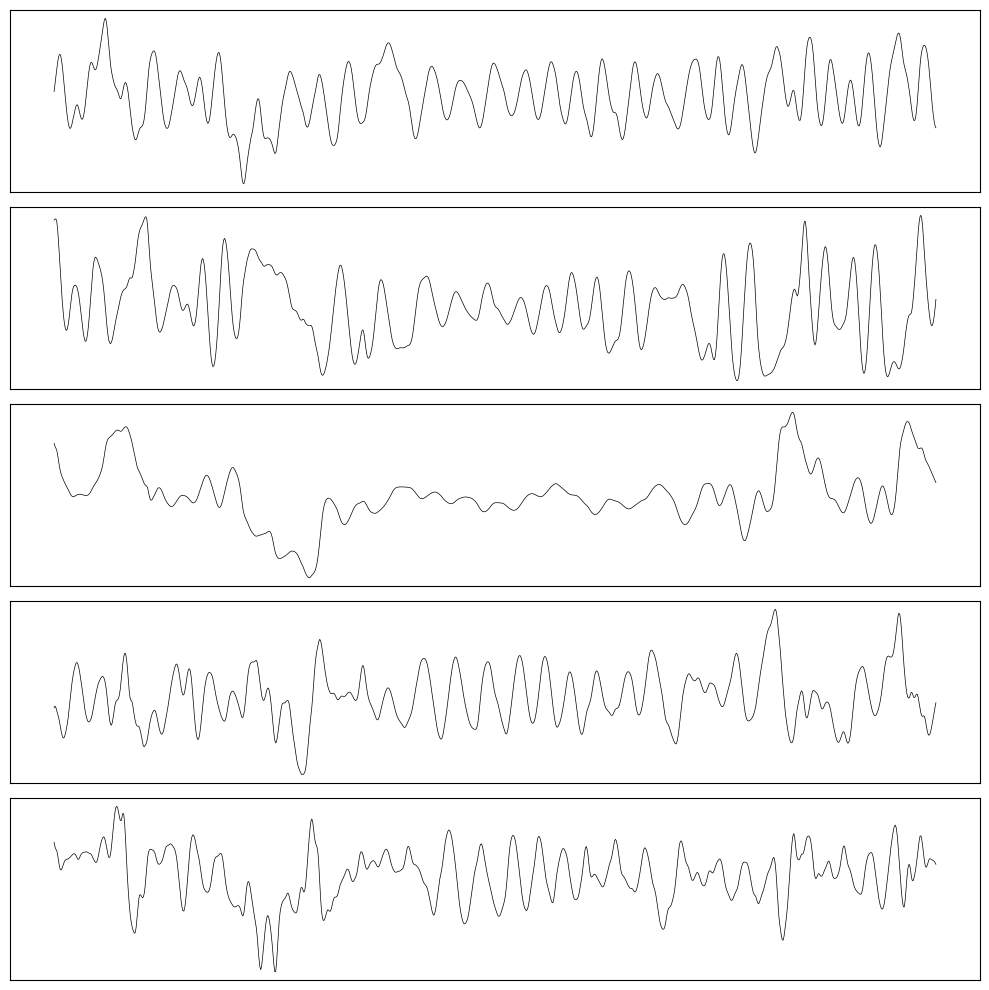

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(10, 10))

for i in range(5):
    axes[i].plot(read_data_slice[i, :1000], linewidth=0.5, color='black')
    # axes[i].set_ylabel(f'Dim {i}')
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('read_data_slice.svg', format='svg', transparent=True)
plt.savefig('read_data_slice.pdf', format='pdf', bbox_inches='tight')
plt.show()


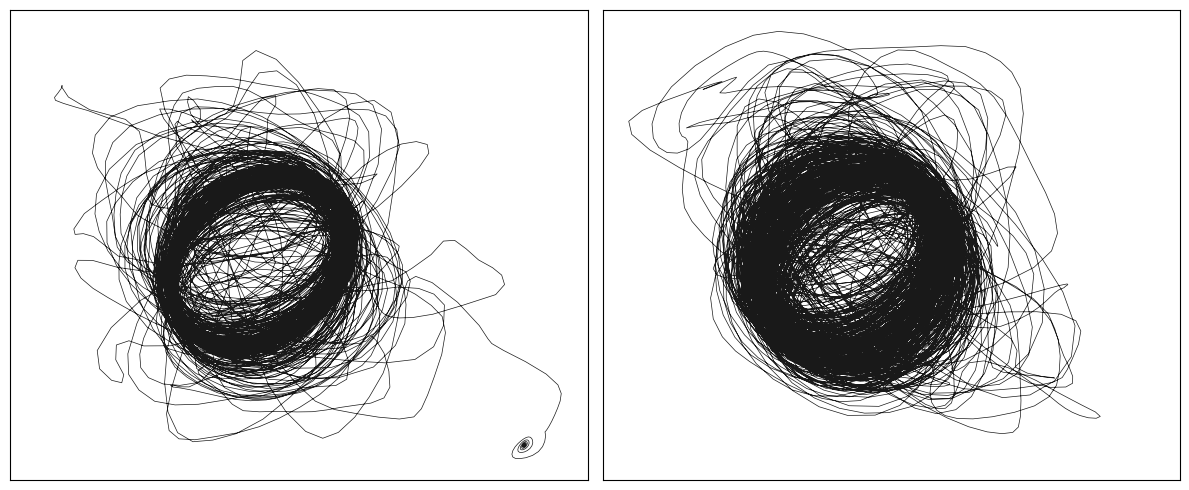

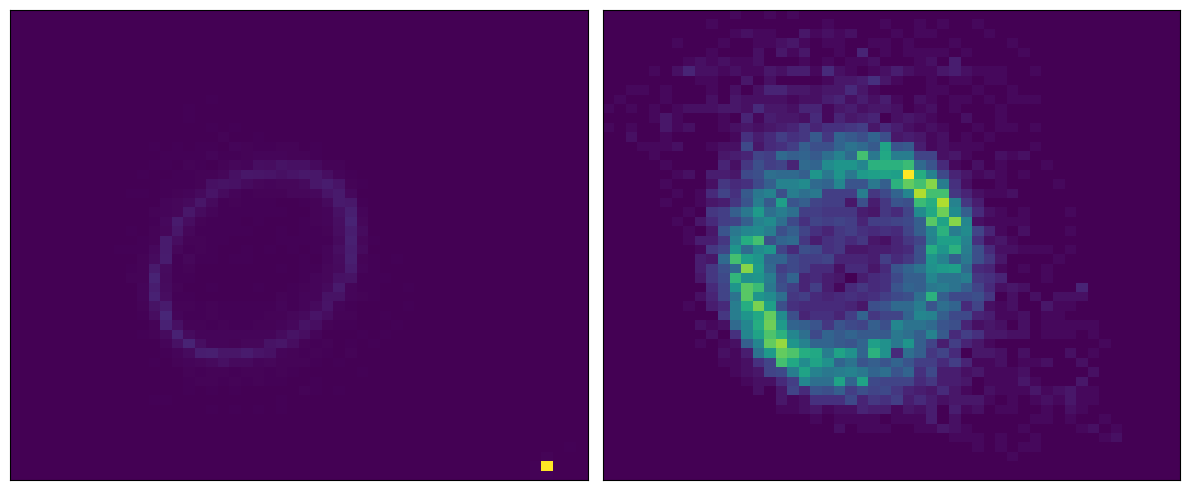

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_min = min(predictions[0, :].min(), read_data_slice[0, :].min())
x_max = max(predictions[0, :].max(), read_data_slice[0, :].max())
y_min = min(predictions[1, :].min(), read_data_slice[1, :].min())
y_max = max(predictions[1, :].max(), read_data_slice[1, :].max())

x_padding = (x_max - x_min) * 0.05
y_padding = (y_max - y_min) * 0.05

ax1.plot(predictions[0, :], predictions[1, :], 'black', linewidth=0.5, alpha=0.9)

ax1.set_xlim(x_min - x_padding, x_max + x_padding)
ax1.set_ylim(y_min - y_padding, y_max + y_padding)
ax1.set_xticks([])
ax1.set_yticks([])

ax2.plot(read_data_slice[0, :], read_data_slice[1, :], 'black', linewidth=0.5, alpha=0.9)

ax2.set_xlim(x_min - x_padding, x_max + x_padding)
ax2.set_ylim(y_min - y_padding, y_max + y_padding)
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
# plt.savefig('prediction_vs_real.svg', format='svg', transparent=True)
# plt.savefig('prediction_vs_real.pdf', format='pdf', bbox_inches='tight')
plt.show()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_min = min(predictions[0, :].min(), read_data_slice[0, :].min())
x_max = max(predictions[0, :].max(), read_data_slice[0, :].max())
y_min = min(predictions[1, :].min(), read_data_slice[1, :].min())
y_max = max(predictions[1, :].max(), read_data_slice[1, :].max())

ax1.hist2d(predictions[0, :], predictions[1, :], bins=50, range=[[x_min, x_max], [y_min, y_max]])
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.set_xticks([])
ax1.set_yticks([])

ax2.hist2d(read_data_slice[0, :], read_data_slice[1, :], bins=50, range=[[x_min, x_max], [y_min, y_max]])
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
# plt.savefig('histogram_prediction.svg', format='svg', transparent=True)
# plt.savefig('histogram_real.svg', format='svg', transparent=True)
plt.show()

In [ ]:
plt

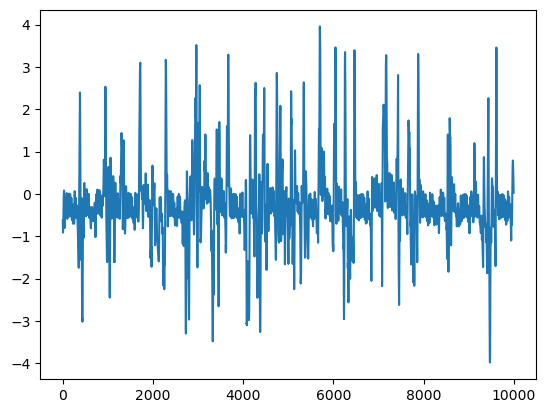

In [44]:
plt.plot(predictions[2])

In [ ]:
spectrum_11 = esn.lyapunov_spectrum(worm_N2_scaled[:inputdim, 2000:], 20, 2500, 2, 1/16, 2, 2000, 500, False)

In [194]:
spectrum_11

{'mean': array([  0.44483757,   0.15561449,  -0.0196263 ,  -0.24651517,
         -0.58737427,  -0.97923908,  -1.53259712,  -2.24590601,
         -3.70640881,  -4.59537752,  -6.06369305,  -6.60755962,
         -7.17751546, -13.18771714, -14.14907079, -16.24792288,
        -16.2614284 , -16.26491728, -16.26972117, -16.27591257]),
 'std': array([0.01866292, 0.03594992, 0.00588497, 0.01256441, 0.05146395,
        0.00524311, 0.02873766, 0.08803605, 0.18312514, 0.1538319 ,
        0.24053074, 0.14542273, 0.2488772 , 0.02872704, 0.09850199,
        0.03425033, 0.02438958, 0.02682684, 0.03137753, 0.03142114]),
 'all_samples': array([[ 4.26174645e-01,  1.91564405e-01, -1.37413319e-02,
         -2.59079582e-01, -6.38838221e-01, -9.73995968e-01,
         -1.56133478e+00, -2.33394206e+00, -3.88953395e+00,
         -4.74920942e+00, -6.30422379e+00, -6.75298235e+00,
         -7.42639266e+00, -1.32164442e+01, -1.42475728e+01,
         -1.62858180e+01, -1.62821732e+01, -1.62917441e+01,
         -1.63

In [39]:
spectrum

{'mean': array([  1.25351706,   0.67674797,   0.12423812,  -0.13843588,
         -0.77580118,  -1.71561492,  -2.84555625,  -3.91170522,
         -5.2628692 ,  -7.11835549,  -8.31801684,  -9.22305383,
        -10.42555115, -12.30414877, -14.52889942, -16.66923085,
        -16.68082948, -16.6825109 , -16.68369574, -16.69782141]),
 'std': array([0.03703471, 0.01790167, 0.00840651, 0.03343826, 0.02703062,
        0.00456531, 0.02755786, 0.03660152, 0.02559985, 0.00291521,
        0.06808564, 0.07922261, 0.02010827, 0.02641263, 0.09005721,
        0.00402593, 0.00659893, 0.00722425, 0.0066208 , 0.00234017]),
 'all_samples': array([[  1.29055177,   0.6588463 ,   0.11583161,  -0.17187414,
          -0.8028318 ,  -1.72018023,  -2.87311411,  -3.94830675,
          -5.28846905,  -7.11544028,  -8.2499312 ,  -9.30227644,
         -10.40544287, -12.3305614 , -14.61895663, -16.66520492,
         -16.67528665, -16.67423055, -16.67707494, -16.70016158],
        [  1.21648235,   0.69464964,   0.1326446

In [ ]:
spectrum_resampled = esn_resampled.lyapunov_spectrum(worm_N2_scaled_resampled[:inputdim, 2000:], 20, 2500, 1, 2/16, 1, 2000, 500, False)

In [8]:
sys.path.append('/Users/iliasoroka/ReservoirComputing')
from optimisation import ESNSearchSpaceBuilder, EvaluationConfig, optimize_esn
from esn import ESN, logger

In [183]:
space = (ESNSearchSpaceBuilder()
    .optimize("spectral_radius", bounds=(0.05, 3))  
    .optimize("alpha", bounds=(0.00001, 25), log_scale=True)         
    .optimize("input_scaling", bounds=(0.01, 2))
    .optimize("leaky_rate", bounds=(0.01, 1))
    .optimize("bias_scaling", bounds=(0.01, 2))
    .fix(N=10000, mode="leaky", sparsity=0.99)
    .build())

In [184]:
config_eval = EvaluationConfig(
    washout=5000,
    warmup_steps=2000,
    predict_steps=7500,
    n_predictions=4,   
    n_instances=5,     
    clip_wasserstein=3,
    constrain_cle=True,
    cle_threshold=-10,  
    metrics=["wasserstein"]
)

In [155]:
import warnings
import logging

logging.getLogger('ax').setLevel(logging.DEBUG)
logging.getLogger('esn').setLevel(logging.DEBUG)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', module='botorch')
warnings.filterwarnings('ignore', module='gpytorch')
warnings.filterwarnings('ignore', category=RuntimeWarning, module='linear_operator')

best_params, best_ax, ax_client = optimize_esn(data = worm_N2_scaled, space = space, config = config_eval, n_trials = 30)

[INFO 01-24 23:42:14] ax.generation_strategy.dispatch_utils: Using Generators.BOTORCH_MODULAR since there is at least one ordered parameter and there are no unordered categorical parameters.
[INFO 01-24 23:42:14] ax.generation_strategy.dispatch_utils: Using Bayesian Optimization generation strategy: GenerationStrategy(name='Sobol+BoTorch', steps=[Sobol for 10 trials, BoTorch for subsequent trials]). Iterations after 10 will take longer to generate due to model-fitting.


{'spectral_radius': 1.4938864901661875, 'alpha': 0.002292287571441594, 'input_scaling': 1.7587696051597594, 'leaky_rate': 0.8029427921772003, 'bias_scaling': 0.5893357837200165}
{'wasserstein': (np.float64(0.8670047524106258), np.float64(0.3030767235484424)), 'max_cle': (np.float64(-6.632679528571944), np.float64(0.01780353720627805))}
{'spectral_radius': 1.768673833552748, 'alpha': 3.137921466336249, 'input_scaling': 0.22191494091413916, 'leaky_rate': 0.3408380305860192, 'bias_scaling': 1.5227629875857382}
{'wasserstein': (np.float64(2.6514400572553054), np.float64(0.35696064135090144)), 'max_cle': (np.float64(-0.4512488644658299), np.float64(0.022420596296033567))}
{'spectral_radius': 2.4548746202141047, 'alpha': 8.080171244265176e-05, 'input_scaling': 1.1191020979080348, 'leaky_rate': 0.5276895676366985, 'bias_scaling': 1.2183392691239714}
{'wasserstein': (np.float64(0.6683438942941649), np.float64(0.004914387138545857)), 'max_cle': (np.float64(-0.5963286490405235), np.float64(0.008

In [165]:
final_config = space.build_config(best_params, input_dim=worm_N2_scaled.shape[0])

In [166]:
final_config

ESNConfig(N=5500, input_dim=5, spectral_radius=0.9465829876443707, alpha=25.0, sparsity=0.99, input_scaling=1.931575343525047, bias_scaling=0.6857760505123052, seed=None, weights_generation_strategy='Gaussian', bias_generation_strategy='Uniform', input_generation_strategy='Uniform', self_connections=False, dtype=dtype('float64'), mode='leaky', leaky_rate=0.7088218951135763, beta=0.5, scale=0.1)

In [167]:
esn = ESN(final_config)

In [168]:
esn.train(worm_N2_scaled, washout=2000)

In [179]:
predictions, states = esn.predict(warmup=worm_N2_scaled[:, 2000:4000], steps=10000)

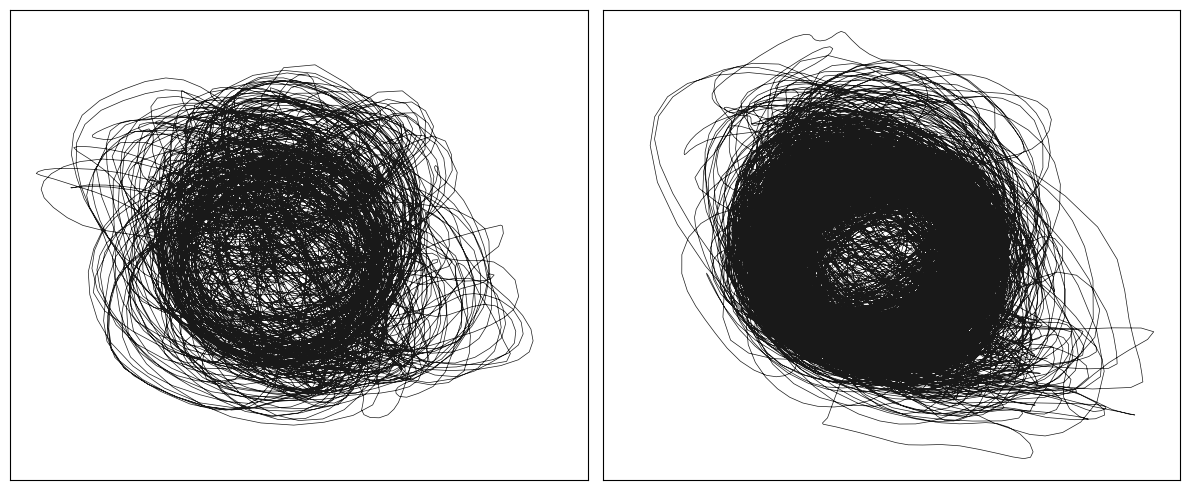

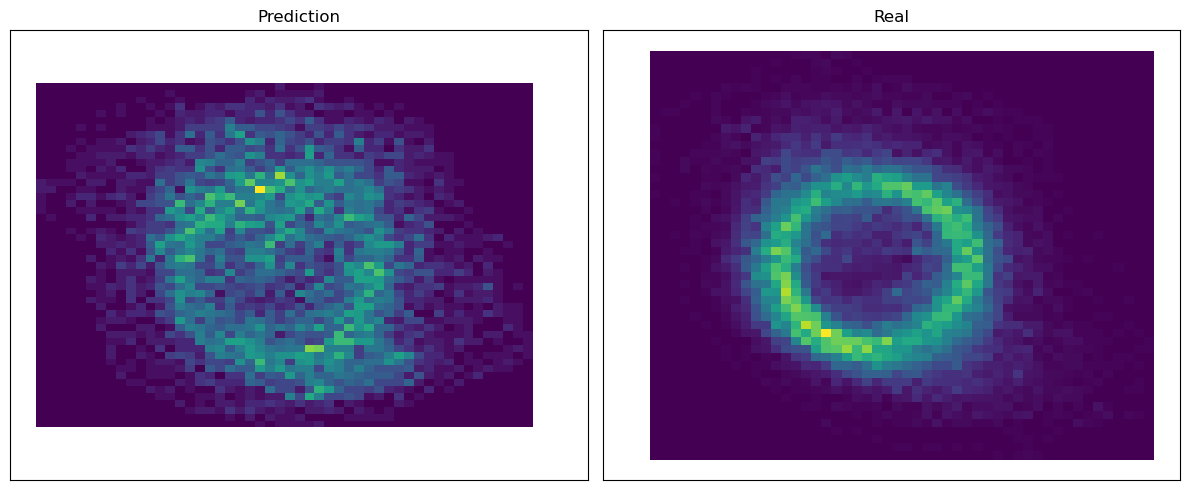

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_min = min(predictions[0, :].min(), worm_N2_scaled[0, :].min())
x_max = max(predictions[0, :].max(), worm_N2_scaled[0, :].max())
y_min = min(predictions[1, :].min(), worm_N2_scaled[1, :].min())
y_max = max(predictions[1, :].max(), worm_N2_scaled[1, :].max())

x_padding = (x_max - x_min) * 0.05
y_padding = (y_max - y_min) * 0.05

ax1.plot(predictions[0, :], predictions[1, :], 'black', linewidth=0.5, alpha=0.9)

ax1.set_xlim(x_min - x_padding, x_max + x_padding)
ax1.set_ylim(y_min - y_padding, y_max + y_padding)
ax1.set_xticks([])
ax1.set_yticks([])

ax2.plot(worm_N2_scaled[0, :], worm_N2_scaled[1, :], 'black', linewidth=0.5, alpha=0.9)

ax2.set_xlim(x_min - x_padding, x_max + x_padding)
ax2.set_ylim(y_min - y_padding, y_max + y_padding)
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
# plt.savefig('prediction_vs_real.svg', format='svg', transparent=True)
# plt.savefig('prediction_vs_real.pdf', format='pdf', bbox_inches='tight')
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist2d(predictions[0, :], predictions[1, :], bins=50, cmap='viridis')
ax1.set_xlim(x_min - x_padding, x_max + x_padding)
ax1.set_ylim(y_min - y_padding, y_max + y_padding)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title('Prediction')

ax2.hist2d(worm_N2_scaled[0, :], worm_N2_scaled[1, :], bins=50, cmap='viridis')
ax2.set_xlim(x_min - x_padding, x_max + x_padding)
ax2.set_ylim(y_min - y_padding, y_max + y_padding)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title('Real')

plt.tight_layout()
plt.show()

In [171]:
conditional_lyapunov_spectrum = esn.conditional_lyapunov_spectrum(worm_N2_scaled[:5, :50000],
                                                        num_lyaps=1,
                                                        norm_time=2,
                                                        dt=1/16)

In [181]:
conditional_lyapunov_spectrum

{'exponents': array([-9.28500587]),
 'convergence': None,
 'max_cle': np.float64(-9.285005867960326),
 'sum_cle': np.float64(-9.285005867960326),
 'num_renorms': 13685}

In [173]:
spectrum = esn.lyapunov_spectrum(worm_N2_scaled[:5, 2000:], 20, 4500, 2, 1/16, 5, 2000, 500, False)

In [182]:
spectrum['mean']

array([  1.71725003,   0.8777076 ,   0.21542042,  -0.34513014,
        -1.21319395,  -2.26483717,  -3.35977947,  -4.63228115,
        -5.74105314,  -6.80395895,  -7.64818157,  -8.17322509,
        -8.58264054,  -9.08991702,  -9.30775018,  -9.65388257,
        -9.80535964,  -9.92535784, -10.01499142, -10.10279303])

In [24]:
import pickle

with open('/Users/iliasoroka/RC/spectrum.pkl', 'rb') as f:
    spectrum_1 = pickle.load(f)

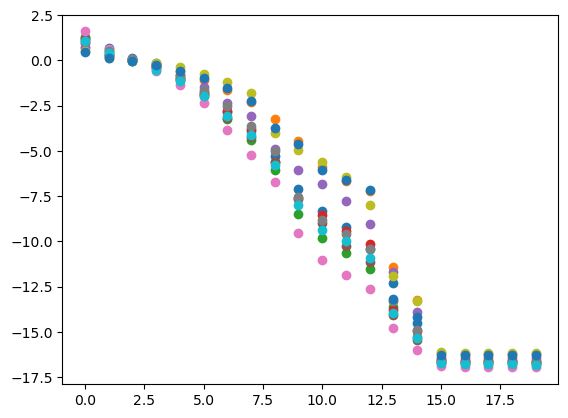

In [195]:
plt.plot(spectrum['mean'], 'o')
plt.plot(spectrum_1['mean'], 'o')
plt.plot(spectrum_2['mean'], 'o')
plt.plot(spectrum_3['mean'], 'o')
plt.plot(spectrum_4['mean'], 'o')
plt.plot(spectrum_6['all_samples'][1], 'o')
plt.plot(spectrum_7['mean'], 'o')
plt.plot(spectrum_8['mean'], 'o')
plt.plot(spectrum_9['mean'], 'o')
plt.plot(spectrum_10['all_samples'][1], 'o')
plt.plot(spectrum_11['mean'], 'o')
plt.show()

In [ ]:
import pickle

spectra_list = [
    spectrum,
    spectrum_1,
    spectrum_2,
    spectrum_3,
    spectrum_4,
    spectrum_6,
    spectrum_7,
    spectrum_8,
    spectrum_9,
    spectrum_10,
    spectrum_11,
]

with open('/Users/iliasoroka/ReservoirComputing/spectra_list.pkl', 'wb') as f:
    pickle.dump(spectra_list, f)


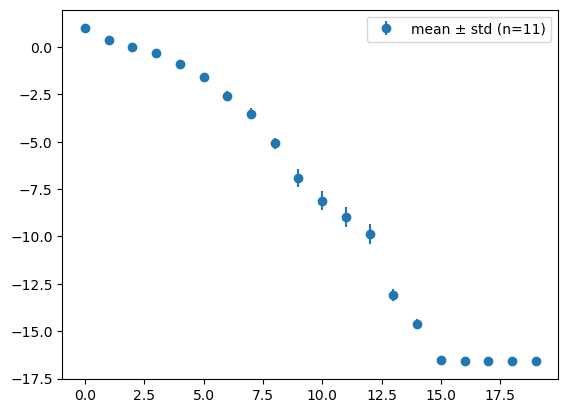

In [ ]:
import numpy as np

means_list = [
    spectrum['mean'],
    spectrum_1['mean'],
    spectrum_2['mean'],
    spectrum_3['mean'],
    spectrum_4['mean'],
    spectrum_6['all_samples'][1],
    spectrum_7['mean'],
    spectrum_8['mean'],
    spectrum_9['mean'],
    spectrum_10['all_samples'][1],
    spectrum_11['mean'],
]

means_arr = np.vstack(means_list)
mean_of_means = np.mean(means_arr, axis=0)
std_of_means = np.std(means_arr, axis=0)

plt.errorbar(
    np.arange(len(mean_of_means)),
    mean_of_means,
    yerr=std_of_means/np.sqrt(11),
    fmt='o',
    label='mean ± std '
)

plt.legend()
plt.show()

In [ ]:
lyap_exponents = spectrum['mean']
cumulative_sum = 0
j = -1

for i, exp in enumerate(lyap_exponents):
    cumulative_sum += exp
    if cumulative_sum >= 0:
        j = i
    else:
        break

if j >= 0 and j < len(lyap_exponents) - 1:
    sum_up_to_j = np.sum(lyap_exponents[:j+1])
    ky_dimension = j + 1 + sum_up_to_j / abs(lyap_exponents[j + 1])
elif j >= 0:
    ky_dimension = j + 1
else:
    ky_dimension = 0

print(f"Kaplan-Yorke dimension: {ky_dimension}")
ky_dimension

Kaplan-Yorke dimension: 6.279498994680238


np.float64(6.279498994680238)

In [127]:
conditional_lyapunov_spectrum

{'exponents': array([-7.84495696]),
 'convergence': None,
 'max_cle': np.float64(-7.844956962748173),
 'sum_cle': np.float64(-7.844956962748173),
 'num_renorms': 13685}

In [64]:
from ot.lp.solver_1d import wasserstein_1d


In [98]:
spectrum_resampled['mean']/(1/16)*(2/16)

array([  2.43735697,   1.25117259,  -0.06108827,  -1.00031838,
        -2.14829651,  -3.56379808,  -5.15463115,  -6.95324515,
        -8.54614827, -10.02880551, -12.76538347, -13.65764839,
       -16.1242648 , -18.01333701, -25.19766546, -32.18389949,
       -32.1846551 , -32.23143736, -32.23580809, -32.25401438])

In [111]:
esn_resampled.save('esn_resampled.pkl')

In [ ]:
import pickle

with open('spectrum.pkl', 'wb') as f:
    pickle.dump(spectrum, f)

spectrum

{'mean': array([ 7.08974610e-01,  2.42320109e-01,  4.05161052e-03, -2.15099287e-01,
        -5.87733678e-01, -1.07464417e+00, -1.65300763e+00, -2.31251915e+00,
        -3.23787708e+00, -4.47262878e+00, -5.90416130e+00, -6.65752845e+00,
        -7.19350984e+00, -1.14326151e+01, -1.32602250e+01, -1.61875325e+01,
        -1.62008310e+01, -1.62122037e+01, -1.62132207e+01, -1.62194188e+01]),
 'std': array([0.10424236, 0.07686225, 0.02803245, 0.06006936, 0.05924392,
        0.07808707, 0.14271411, 0.13930264, 0.23094478, 0.31742409,
        0.21069004, 0.29175432, 0.32616875, 0.1806267 , 0.1397625 ,
        0.03687436, 0.03512281, 0.03546906, 0.03798476, 0.03897983]),
 'all_samples': array([[ 7.97029719e-01,  3.22324877e-01, -1.54959764e-02,
         -2.48776377e-01, -6.39409347e-01, -1.07996660e+00,
         -1.83200487e+00, -2.40158850e+00, -3.50521394e+00,
         -4.50339021e+00, -5.94382269e+00, -6.83798227e+00,
         -7.33018973e+00, -1.14854848e+01, -1.33495761e+01,
         -1.61

In [112]:
with open('spectrum_resampled.pkl', 'wb') as f:
    pickle.dump(spectrum_resampled, f)


In [80]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


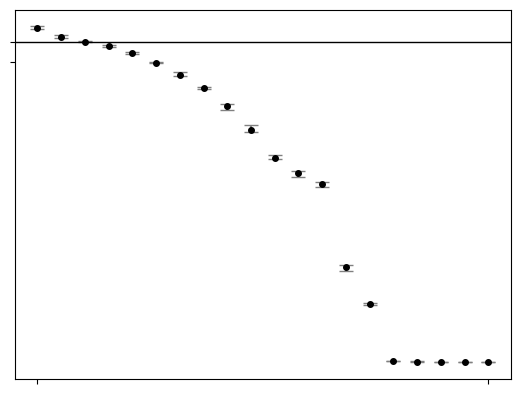

In [83]:
plt.figure()

all_samples = spectrum['all_samples']
median_lyapunov = np.median(all_samples, axis=0)

n_bootstraps = 1000
bootstrap_medians = []
for _ in range(n_bootstraps):
    resample_idxs = np.random.choice(len(all_samples), len(all_samples), replace=True)
    resample = all_samples[resample_idxs]
    bootstrap_medians.append(np.median(resample, axis=0))

bootstrap_medians = np.array(bootstrap_medians)
ci_lower = np.percentile(bootstrap_medians, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_medians, 97.5, axis=0)
yerr = np.array([median_lyapunov - ci_lower, ci_upper - median_lyapunov])

img = plt.errorbar(range(1, len(median_lyapunov) + 1), median_lyapunov,
                   yerr=yerr, fmt='k.', ms=8, capsize=5, 
                   ecolor='gray')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.xticks([1, len(median_lyapunov)], ['', ''])
plt.yticks([0, -1], ['', ''])
plt.minorticks_off()
plt.savefig('lyapunov_spectrum.svg', format='svg', transparent=True)
plt.savefig('lyapunov_spectrum.pdf', format='pdf', bbox_inches='tight')
plt.show()

# axins = inset_axes(plt.gca(), width="40%", height="40%", loc='lower left')

# yerr_inset = np.array([median_lyapunov[:8] - ci_lower[:8], 
#                        ci_upper[:8] - median_lyapunov[:8]])
# axins.errorbar(range(1, 9), median_lyapunov[:8], yerr=yerr_inset, 
#                fmt='k.', ms=8, capsize=5, ecolor='gray')

# axins.axhline(y=0, color='black', linestyle='-', linewidth=1)

# axins.set_xticks([1, 4], ['', ''])
# axins.set_yticklabels([])
# axins.tick_params(labelsize=18)
# axins.minorticks_off()

plt.show()

In [132]:
spectrum_resampled_adjusted

{'mean': array([ 0.60933924,  0.31279315, -0.01527207, -0.25007959, -0.53707413,
        -0.89094952, -1.28865779, -1.73831129, -2.13653707, -2.50720138,
        -3.19134587, -3.4144121 , -4.0310662 , -4.50333425, -6.29941637,
        -8.04597487, -8.04616378, -8.05785934, -8.05895202, -8.06350359]),
 'std': array([0.3162305 , 0.22525216, 0.20138248, 0.09876453, 0.16787129,
        0.31293545, 0.51391391, 0.6969062 , 0.927496  , 1.13343548,
        0.80997608, 0.95064101, 1.20340826, 1.01453643, 0.63077597,
        0.20462763, 0.19723926, 0.19848093, 0.19719211, 0.19791845]),
 'all_samples': array([[ 0.56517008,  0.31279315, -0.01527207, -0.33114606, -0.5687197 ,
         -0.95802879, -1.33781688, -1.75310177, -2.13653707, -2.50720138,
         -3.2485219 , -3.4144121 , -4.12864672, -4.50333425, -6.40370116,
         -8.05867539, -8.06347722, -8.06104789, -8.06621542, -8.06792714],
        [ 0.74742201,  0.41004597,  0.07559015, -0.23087836, -0.62483684,
         -1.01224916, -1.508900

In [ ]:
def calculate_ky_dimension(lyapunov_exponents):
    sorted_exps = np.sort(lyapunov_exponents)[::-1]
    
    cumsum = np.cumsum(sorted_exps)
    
    j = np.where(cumsum >= 0)[0]
    
    if len(j) == 0:
        return 0.0
    
    j = j[-1]  
    
    if j == len(sorted_exps) - 1:
        return float(len(sorted_exps))
    
    sum_j = cumsum[j]
    lambda_j_plus_1 = abs(sorted_exps[j + 1])
    
    if lambda_j_plus_1 == 0:
        return float(j + 1)
    
    d_ky = (j + 1) + sum_j / lambda_j_plus_1
    
    return d_ky

ky_dimension = calculate_ky_dimension(spectrum_resampled_adjusted['mean'])
print(f"Kaplan-Yorke dimension: {ky_dimension:.4f}")

ky_dimensions = []
for sample in spectrum_resampled_adjusted['all_samples']:
    ky_dimensions.append(calculate_ky_dimension(sample))

ky_dimensions = np.array(ky_dimensions)
print(f"KY dimension (mean ± std): {np.mean(ky_dimensions):.4f} ± {np.std(ky_dimensions):.4f}")
print(f"KY dimension (median): {np.median(ky_dimensions):.4f}")


Kaplan-Yorke dimension: 5.1344
KY dimension (mean ± std): 5.0344 ± 0.5095
KY dimension (median): 5.1576


In [150]:
conditional_lyapunov_spectrum = esn.conditional_lyapunov_spectrum(worm_N2_scaled[:inputdim, :10000],
                                                        num_lyaps=1,
                                                        norm_time=2,
                                                        dt=1/16)

In [21]:
conditional_lyapunov_spectrum_resampled = esn_resampled.conditional_lyapunov_spectrum(worm_N2_scaled_resampled[:inputdim, :10000],
                                                        num_lyaps=1,
                                                        norm_time=2,
                                                        dt=2/16)

In [22]:
conditional_lyapunov_spectrum_resampled

{'exponents': array([-8.27043298]),
 'convergence': None,
 'max_cle': np.float64(-8.270432979187275),
 'sum_cle': np.float64(-8.270432979187275),
 'num_renorms': 3750}

In [154]:
conditional_lyapunov_spectrum

{'exponents': array([-16.78739055]),
 'convergence': None,
 'max_cle': np.float64(-16.78739055375376),
 'sum_cle': np.float64(-16.78739055375376),
 'num_renorms': 3750}

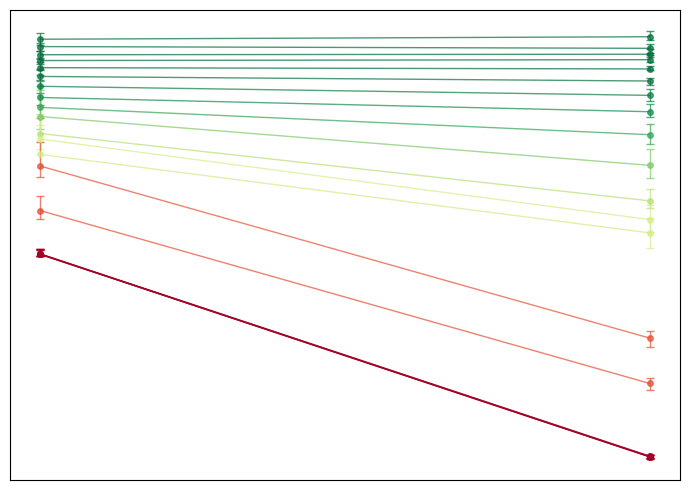

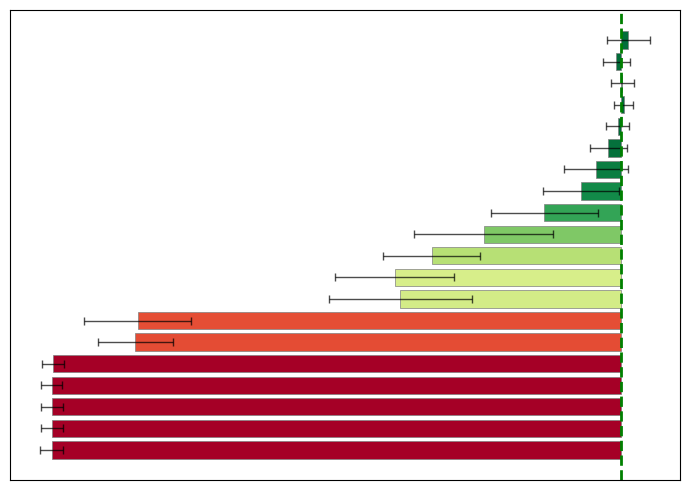

In [ ]:
fig1, ax1 = plt.subplots(1, 1, figsize=(7, 5))

dts = [1/16, 2/16]
spctrums = [[spectrum], [spectrum_resampled_adjusted]]

num_exponents = len(spctrums[0][0]["mean"])

def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_means.append(np.median(sample))
    lower = np.percentile(bootstrap_means, (100 - ci) / 2)
    upper = np.percentile(bootstrap_means, 100 - (100 - ci) / 2)
    return lower, upper

all_data = []
inv_dts = [1/dt for dt in dts]

for exponent_idx in range(min(num_exponents, 40)):
    exponent_values = []
    exponent_errors_lower = []
    exponent_errors_upper = []
    
    for spectrum_list in spctrums:
        all_samples = [spectrum["all_samples"][:, exponent_idx] for spectrum in spectrum_list]
        all_samples_flat = np.concatenate(all_samples)
        
        median_val = np.median(all_samples_flat)
        lower = np.percentile(all_samples_flat, 2.5)
        upper = np.percentile(all_samples_flat, 97.5)
        
        exponent_values.append(median_val)
        exponent_errors_lower.append(abs(median_val - lower))
        exponent_errors_upper.append(abs(upper - median_val))
    
    exponent_errors = [exponent_errors_lower, exponent_errors_upper]
    all_data.append({'values': exponent_values, 'errors': exponent_errors})

slopes = []
slope_errors = []
for data in all_data:
    if len(inv_dts) >= 2:
        slope = (data['values'][-1] - data['values'][0]) / (inv_dts[-1] - inv_dts[0])
        
        n_bootstrap = 4000
        bootstrap_slopes = []
        for _ in range(n_bootstrap):
            sampled_values = []
            for i, val in enumerate(data['values']):
                std_err = (data['errors'][0][i] + data['errors'][1][i]) / (2 * 1.96)
                sampled_val = np.random.normal(val, std_err)
                sampled_values.append(sampled_val)
            
            boot_slope = (sampled_values[-1] - sampled_values[0]) / (inv_dts[-1] - inv_dts[0])
            bootstrap_slopes.append(boot_slope)
        
        slope_lower = np.percentile(bootstrap_slopes, 2.5)
        slope_upper = np.percentile(bootstrap_slopes, 97.5)
        slope_error = (slope_upper - slope_lower) / 2
    else:
        slope = 0
        slope_error = 0
    
    slopes.append(slope)
    slope_errors.append(slope_error)

max_abs_slope = max(abs(s) for s in slopes) if slopes else 1
slope_colors = plt.cm.RdYlGn_r(np.abs(slopes) / max_abs_slope)

for exponent_idx, data in enumerate(all_data):
    ax1.errorbar(inv_dts, data['values'], yerr=data['errors'], marker='o', markersize=4, linewidth=1, alpha=0.7, capsize=3, color=slope_colors[exponent_idx])

ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lyapunov_spectrum_dt_scaling.svg', format='svg', transparent=True)
plt.savefig('lyapunov_spectrum_dt_scaling.pdf', format='pdf', bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(1, 1, figsize=(7, 5))

y_positions = np.arange(len(slopes))
bars = ax2.barh(y_positions, slopes, xerr=slope_errors, color=slope_colors, edgecolor='gray', linewidth=0.5, capsize=3, error_kw={'elinewidth': 1, 'alpha': 0.7})

ax2.axvline(x=0, color='green', linestyle='--', linewidth=2)

ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.invert_yaxis()

plt.tight_layout()
plt.show()